# Probability
**What is Probability?**
Probability is the measure of how likely an event is to occur.
It is a number between 0 and 1.

- 0 → Event will never happen
- 1 → Event will always happen
- 0.5 → Equal chance of happening or not

**Why Probability?**
- Foundation of Statistics and Machine Learning
- Used in Hypothesis Testing
- Used in Naive Bayes, Decision Trees etc.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fractions import Fraction

## Dataset
Self created student dataset with 10 students.
We will use this to calculate real probabilities.

In [2]:
data = {
    "Name"      : ["Piyush", "Vai", "Arpit", "Rahul", "Sneha",
                   "Rohan", "Priya", "Anjali", "Dev", "Kriti"],
    "Age"       : [19, 20, 20, 18, 19, 21, 18, 20, 19, 21],
    "Gender"    : ["Male", "Male", "Male", "Male", "Female",
                   "Male", "Female", "Female", "Male", "Female"],
    "Marks"     : [72, 88, 85, 60, 90, 78, 55, 82, 65, 91],
    "Attendance": [85.0, 95.0, 92.5, 70.0, 98.0, 88.0, 60.5, 91.0, 75.0, 97.0],
    "Passed"    : ["Yes", "Yes", "Yes", "No", "Yes",
                   "Yes", "No", "Yes", "No", "Yes"]
}

df = pd.DataFrame(data)
print(df)

     Name  Age  Gender  Marks  Attendance Passed
0  Piyush   19    Male     72        85.0    Yes
1     Vai   20    Male     88        95.0    Yes
2   Arpit   20    Male     85        92.5    Yes
3   Rahul   18    Male     60        70.0     No
4   Sneha   19  Female     90        98.0    Yes
5   Rohan   21    Male     78        88.0    Yes
6   Priya   18  Female     55        60.5     No
7  Anjali   20  Female     82        91.0    Yes
8     Dev   19    Male     65        75.0     No
9   Kriti   21  Female     91        97.0    Yes


## 1. Basic Probability

**Formula:**
P(Event) = Number of Favorable Outcomes / Total Outcomes

**Example:**
P(Passing) = Number of students who passed / Total students

In [3]:
total = len(df)

# P(Passed)
passed = len(df[df["Passed"] == "Yes"])
p_passed = passed / total
print(f"Total Students     : {total}")
print(f"Students Passed    : {passed}")
print(f"P(Passed)          : {p_passed} = {Fraction(passed, total)}")

# P(Failed)
failed = len(df[df["Passed"] == "No"])
p_failed = failed / total
print(f"\nStudents Failed    : {failed}")
print(f"P(Failed)          : {p_failed} = {Fraction(failed, total)}")

# Verify → P(Pass) + P(Fail) should = 1
print(f"\nP(Pass) + P(Fail)  : {p_passed + p_failed}")

Total Students     : 10
Students Passed    : 7
P(Passed)          : 0.7 = 7/10

Students Failed    : 3
P(Failed)          : 0.3 = 3/10

P(Pass) + P(Fail)  : 1.0


In [4]:
# P(Male)
males = len(df[df["Gender"] == "Male"])
p_male = males / total
print(f"P(Male)            : {p_male} = {Fraction(males, total)}")

# P(Female)
females = len(df[df["Gender"] == "Female"])
p_female = females / total
print(f"P(Female)          : {p_female} = {Fraction(females, total)}")

# P(Marks > 80)
high_marks = len(df[df["Marks"] > 80])
p_high = high_marks / total
print(f"\nP(Marks > 80)      : {p_high} = {Fraction(high_marks, total)}")

# P(Attendance > 90)
high_attend = len(df[df["Attendance"] > 90])
p_attend = high_attend / total
print(f"P(Attendance > 90) : {p_attend} = {Fraction(high_attend, total)}")

P(Male)            : 0.6 = 3/5
P(Female)          : 0.4 = 2/5

P(Marks > 80)      : 0.5 = 1/2
P(Attendance > 90) : 0.5 = 1/2


## 2. Complementary Probability

The probability of an event NOT happening.

**Formula:**
P(A') = 1 - P(A)

**Example:**
P(Not Passed) = 1 - P(Passed)

In [5]:
print("Complementary Probability")

p_passed = len(df[df["Passed"] == "Yes"]) / total
p_not_passed = 1 - p_passed
print(f"P(Passed)          : {p_passed}")
print(f"P(Not Passed)      : {p_not_passed}")

p_male = len(df[df["Gender"] == "Male"]) / total
p_not_male = 1 - p_male
print(f"\nP(Male)            : {p_male}")
print(f"P(Not Male)        : {p_not_male}")

Complementary Probability
P(Passed)          : 0.7
P(Not Passed)      : 0.30000000000000004

P(Male)            : 0.6
P(Not Male)        : 0.4


## 3. Joint Probability — AND

Probability of TWO events happening together.

**Formula:**
P(A AND B) = P(A∩B) = Favorable outcomes for both / Total

**Example:**
P(Male AND Passed) = Students who are Male AND Passed / Total

In [6]:
print("Joint Probability (AND)")

# P(Male AND Passed)
male_passed = len(df[(df["Gender"] == "Male") & (df["Passed"] == "Yes")])
p_male_passed = male_passed / total
print(f"P(Male AND Passed)         : {p_male_passed} = {Fraction(male_passed, total)}")

# P(Female AND Passed)
female_passed = len(df[(df["Gender"] == "Female") & (df["Passed"] == "Yes")])
p_female_passed = female_passed / total
print(f"P(Female AND Passed)       : {p_female_passed} = {Fraction(female_passed, total)}")

# P(Marks > 80 AND Attendance > 90)
high_both = len(df[(df["Marks"] > 80) & (df["Attendance"] > 90)])
p_high_both = high_both / total
print(f"P(Marks>80 AND Attend>90)  : {p_high_both} = {Fraction(high_both, total)}")

Joint Probability (AND)
P(Male AND Passed)         : 0.4 = 2/5
P(Female AND Passed)       : 0.3 = 3/10
P(Marks>80 AND Attend>90)  : 0.5 = 1/2


## 4. Union Probability — OR

Probability of EITHER event happening.

**Formula:**
P(A OR B) = P(A) + P(B) - P(A AND B)

**Example:**
P(Male OR Passed) = P(Male) + P(Passed) - P(Male AND Passed)

In [7]:
print("Union Probability (OR)")

p_male   = len(df[df["Gender"] == "Male"]) / total
p_passed = len(df[df["Passed"] == "Yes"]) / total
p_male_and_passed = len(df[(df["Gender"] == "Male") & (df["Passed"] == "Yes")]) / total

p_male_or_passed = p_male + p_passed - p_male_and_passed

print(f"P(Male)                : {p_male}")
print(f"P(Passed)              : {p_passed}")
print(f"P(Male AND Passed)     : {p_male_and_passed}")
print(f"P(Male OR Passed)      : {p_male_or_passed}")

Union Probability (OR)
P(Male)                : 0.6
P(Passed)              : 0.7
P(Male AND Passed)     : 0.4
P(Male OR Passed)      : 0.8999999999999998


## 5. Conditional Probability

Probability of event A given that event B has already happened.

**Formula:**
P(A | B) = P(A AND B) / P(B)

**Example:**
P(Passed | Male) = Probability of passing GIVEN the student is Male

In [8]:
print("Conditional Probability")

# P(Passed | Male)
p_male = len(df[df["Gender"] == "Male"]) / total
p_male_and_passed = len(df[(df["Gender"] == "Male") & (df["Passed"] == "Yes")]) / total

p_passed_given_male = p_male_and_passed / p_male
print(f"P(Passed | Male)       : {p_passed_given_male:.2f}")

# P(Passed | Female)
p_female = len(df[df["Gender"] == "Female"]) / total
p_female_and_passed = len(df[(df["Gender"] == "Female") & (df["Passed"] == "Yes")]) / total

p_passed_given_female = p_female_and_passed / p_female
print(f"P(Passed | Female)     : {p_passed_given_female:.2f}")

print(f"\nInterpretation:")
print(f"If a student is Male   → {p_passed_given_male*100:.0f}% chance of passing")
print(f"If a student is Female → {p_passed_given_female*100:.0f}% chance of passing")

Conditional Probability
P(Passed | Male)       : 0.67
P(Passed | Female)     : 0.75

Interpretation:
If a student is Male   → 67% chance of passing
If a student is Female → 75% chance of passing


## 6. Probability Distributions

**Types:**
- Uniform Distribution  → Equal probability for all outcomes
- Normal Distribution   → Bell shaped curve
- Binomial Distribution → Two outcomes (Pass/Fail, Yes/No)

=== Uniform Distribution (Dice Roll) ===
P(Face = 1) : 0.1667
P(Face = 2) : 0.1667
P(Face = 3) : 0.1667
P(Face = 4) : 0.1667
P(Face = 5) : 0.1667
P(Face = 6) : 0.1667


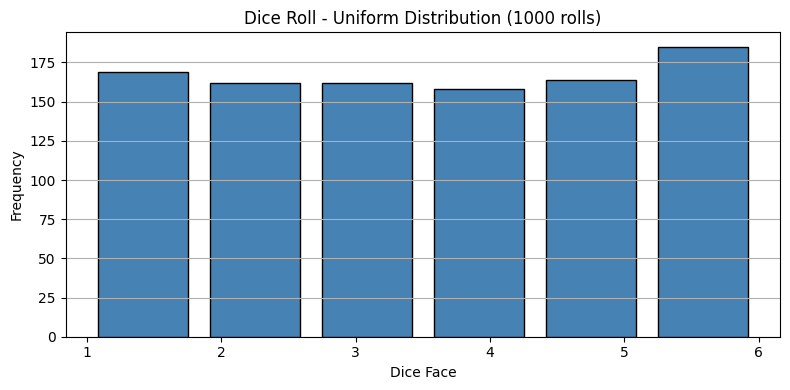

In [9]:
# Rolling a dice → each face has equal probability
dice_faces = [1, 2, 3, 4, 5, 6]
probability = 1 / len(dice_faces)

print("Uniform Distribution (Dice Roll)")
for face in dice_faces:
    print(f"P(Face = {face}) : {probability:.4f}")

# Simulate 1000 dice rolls
rolls = np.random.randint(1, 7, size=1000)

plt.figure(figsize=(8, 4))
plt.hist(rolls, bins=6, color="steelblue", edgecolor="black", rwidth=0.8)
plt.title("Dice Roll - Uniform Distribution (1000 rolls)")
plt.xlabel("Dice Face")
plt.ylabel("Frequency")
plt.xticks([1, 2, 3, 4, 5, 6])
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Normal Distribution
Bell shaped curve.
Most values are near the mean.
Data is symmetric around the mean.

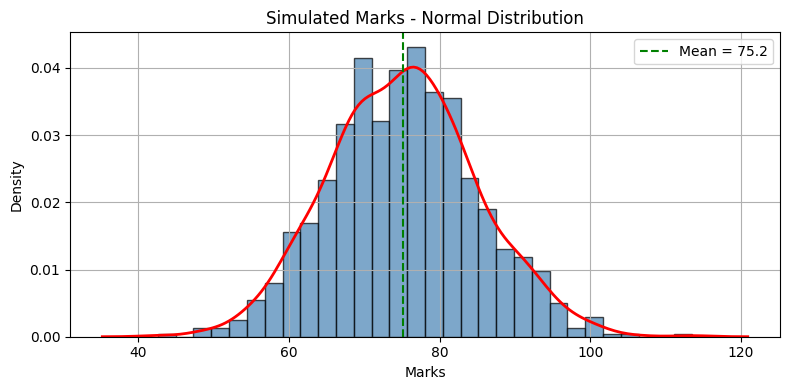

Mean   : 75.19
Std Dev: 9.79


In [10]:
# Simulate marks of 1000 students
np.random.seed(42)
simulated_marks = np.random.normal(loc=75, scale=10, size=1000)

plt.figure(figsize=(8, 4))
plt.hist(simulated_marks, bins=30, color="steelblue",
         edgecolor="black", density=True, alpha=0.7)
sns.kdeplot(simulated_marks, color="red", linewidth=2)
plt.axvline(np.mean(simulated_marks), color="green",
            linestyle="--", label=f"Mean = {np.mean(simulated_marks):.1f}")
plt.title("Simulated Marks - Normal Distribution")
plt.xlabel("Marks")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Mean   : {np.mean(simulated_marks):.2f}")
print(f"Std Dev: {np.std(simulated_marks):.2f}")

## Binomial Distribution
Used when there are only TWO outcomes.
Example → Pass or Fail, Yes or No, Head or Tail.

**Formula:**
P(X = k) = C(n,k) * p^k * (1-p)^(n-k)

Where:
- n = number of trials
- k = number of successes
- p = probability of success

Binomial Distribution
n (students) = 10, p (pass prob) = 0.7

P(exactly  0 pass) : 0.0000
P(exactly  1 pass) : 0.0001
P(exactly  2 pass) : 0.0014
P(exactly  3 pass) : 0.0090
P(exactly  4 pass) : 0.0368
P(exactly  5 pass) : 0.1029
P(exactly  6 pass) : 0.2001
P(exactly  7 pass) : 0.2668
P(exactly  8 pass) : 0.2335
P(exactly  9 pass) : 0.1211
P(exactly 10 pass) : 0.0282


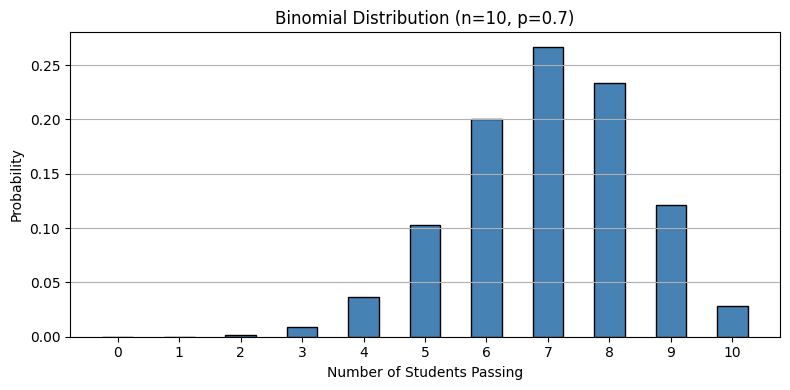

In [11]:
from scipy.stats import binom

# 10 students, probability of passing = 0.7
n = 10
p = 0.7

print("Binomial Distribution")
print(f"n (students) = {n}, p (pass prob) = {p}")
print()

for k in range(n+1):
    prob = binom.pmf(k, n, p)
    print(f"P(exactly {k:2d} pass) : {prob:.4f}")

# Plot
x = np.arange(0, n+1)
y = binom.pmf(x, n, p)

plt.figure(figsize=(8, 4))
plt.bar(x, y, color="steelblue", edgecolor="black", width=0.5)
plt.title(f"Binomial Distribution (n={n}, p={p})")
plt.xlabel("Number of Students Passing")
plt.ylabel("Probability")
plt.xticks(x)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

## Conclusion

In this notebook I covered:

- Basic Probability
- Complementary Probability
- Joint Probability (AND)
- Union Probability (OR)
- Conditional Probability
- Uniform Distribution
- Normal Distribution
- Binomial Distribution